# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [179]:
# importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [180]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [181]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [182]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [183]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [184]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [185]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [186]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [187]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [188]:
# cantidad de nulos para users
print(users.isnull().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [189]:
# cantidad de nulos para usage
print(usage.isnull().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Revisando ambos datasets encontramos que en users tenemos las columnas (city, churn_date) donde tenemos que churn_date sus valores nulos pueden ser esperados dado que la columna representa cuando un cliente abandona el servicio, mas sin embargo city puede que tengamos problemas de captura en el registro 

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint: 
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
      -dataset users: se tienen las columnas:
                  city con 469 nulos con una proporcion de 11.7%
                  churn_date con 3534 con un proporcion de 88.3%
      -dataset usage: se tienen las columnas:
                  duration con 22076 con una proporcion de 55.1%
                  length con 17896 con una proporcion de 44.7%
  - Indica qué harías: ¿imputar, eliminar, ignorar?
        -dataset users: en la columna city se opta por imputar para investigar porque tenemos esos errores de captura, en el caso de la columna churn_date se podria solo ignorar o en su defecto eliminar ya que no implica riesgo en nuestro analisis.
        -dataset usage: en la columna duration y length se sometera a imputacion para revisar las celdas mas a detalle.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [190]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



- La columna `user_id` se pueden observar valores consistentes podemos decir que tenemos indicadores validos y unicos
- La columna `age` caso contrario con esta columna tenemos un valor inconsistente en min con -999 aqui es donde profundizaremos el analisis


In [191]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`se encuentra que la columna `id` esta bien, tenemos un promedio centrado, es secuencias y una desviacion estandar coeherente. Mientras que la columna `user_id` se puede ver que habra valores duplicados o un mismo usuario tenga varias entradas lo cual puede decir que compartar el mismo user_id.
- Las columnas `length` y `duration`, se encuentra que en la columna `duration` tenemos un aproximado del 42% de datos faltantes y se observa una distribucion sesgada, mientras que en `length` tenemos que la desviacion estandar esta muy dispersa, tenemos datos faltantes 

In [192]:
# explorar columnas categóricas de users
columnas_user = users.select_dtypes(include='object').columns
print('Numero de valores unicos')
print(users[columnas_user].nunique())

Numero de valores unicos
first_name       6
last_name        5
city             7
reg_date      3961
plan             2
churn_date     197
dtype: int64


- La columna `city` en esta columna si se tendria que hacer otra verificacion ya que solo se cuenta con 6 entradas lo que resulta imposible que solo 7 cidudes sean las unicas que ingresen.
- La columna `plan` tenemos solo dos valores, lo cual esta correcto ya que solo maneja dos planes

In [193]:

# explorar columna categórica de usage
print(usage['type'].nunique())
print(usage['type'].value_counts())
print(usage['type'].isnull().sum())


2
text    22092
call    17908
Name: type, dtype: int64
0


- La columna `type` no se encuentran valores nulos, tiene dos categorias coherentes, cuenta con una distribucion balanceada.


---
✍️ **Comentario**: 
se hace el siguiente diagnostico con la finalidad de saber que acciones vamos a tomar lo cual se encontro que:
-La columna age contiene valores negativos que conlleva a un sentinels invalido, no existen edades negativas en datos reales. 
-En la columna first_name, solo se encuentran 6 valores unicos, puede estar indicando que los nombres estan altamente duplicados o son satos con poca variacion, mismo caso en la columna last_name. 
-En la columna city solo tiene 7 valores unicos para un dataset LATAM lo cual es poco realista, se esperan ciudades de todo latinoamerica, 
-La columna user_id tiene duplicados, multiples registros comparten el mismo user_id, lo que indica que cada usuario aparece mas de una vez en el dataset.

En el dataset usage encontramos inconsistencias como 
Columna duration con un 42.7% de valores nulos lo cual se profundizara si seran validos o sentinals
Columna length  se encuentra con un 44.7%, ademas se encuentra un outlier extremo con valor maximo de 1490 mucho mas alto que el rango normal
valores ceros tanto en la columna duration y como length tienen minimo en 0 pero no esta claro si representa sin valor o  es un valor valido.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  en la columna age, length y duration
- ¿Qué acción tomarías?  imputar datos con mediana para evitar sesgos por outliers, y en length y duration verificar si son datos reales 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [195]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = users['reg_date'].astype(str)
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [171]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")
print(users['reg_date'].dtype)


datetime64[ns]


In [196]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")

In [197]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, dado que tenemos registros hasta el año `2024` tenemos datos registrados en el año `2026` se tendra que revisar el porque esta el error de captura en las fechas

In [198]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, dado que nos centramos que los datos son hasta el año `2024` tenemos casi todos los registros en el `2024` lo cual es imposible ya que tenemos registros en otros años 

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías**

Dataset users 
en la columna reg_date se encuentran fechas futuras hay 40 registros de fechas, lo cual resulta imposible porque los datos solo llegan hasta el año 2024, se encuentra una distribucion desbalanceada, acciones a tomar, eliminar fechas futuras, borrar registros donde sea mayor a 2024, validar fechas nulas, revisar si hay valores nulos tras la conversion. si los hay, decidir si eliminar o imputar, verificar rango valido

dataset usage
primero que nada investifar la concentracion en 2024, cconfirmar si es normal que casi toda la actividad sea reciente, o si hay un problema de datos historicos, validad fechas nulas, tras la conversion y tratar segun corresopnda. 

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? Si aparecen registros con el año 2026
- ¿Qué harías con ellas? verifivar si las entradas fueron error o si son datos corruptos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [152]:

# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)


# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [153]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [199]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024, pd.NA)

# Verificar cambios
users['reg_date'].describe()



count                    3960
unique                   3960
top       1640995200000000000
freq                        1
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [125]:
# Verificación MAR en usage (Missing At Random) para duration
missing_type_by_duration = usage['type'].isna().groupby(usage['duration']).mean() 
print(missing_type_by_duration)

duration
0.00      False
0.01      False
0.02      False
0.03      False
0.04      False
          ...  
42.73     False
45.95     False
46.69     False
46.98     False
120.00    False
Name: type, Length: 2090, dtype: bool


In [126]:
# Verificación MAR en usage (Missing At Random) para length
missing_type_by_length = usage['type'].isna().groupby(usage['length']).mean() 
print(missing_type_by_length)

length
0.0       False
1.0       False
2.0       False
3.0       False
4.0       False
          ...  
122.0     False
123.0     False
124.0     False
125.0     False
1490.0    False
Name: type, Length: 123, dtype: bool


Se realiza la verificacion MAR (Missging At Random) para evaluar la presencia y partones de valores faltantes en las columnas `duration` y `lengt`, no se detectaron valores nulos en ninguna columna, no requiere estrategia de imputacion.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [127]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text': 'sum', 'is_call': 'sum','duration': 'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [128]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [129]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left') 
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,1640995200000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,1641018857914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,1641042515828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,1641066173743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,1641089831657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [130]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [131]:
# Distribución porcentual del tipo de plan
plan_distribution = user_profile['plan'].value_counts(normalize=True) * 100
print(plan_distribution)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

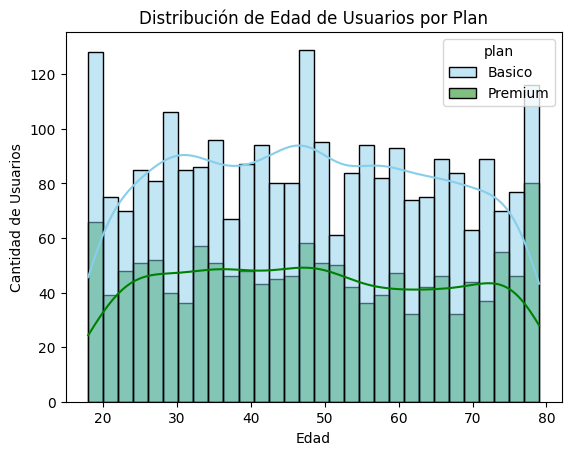

In [132]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', bins=30, kde=True, hue='plan', 
             palette=['skyblue', 'green'], edgecolor='black')
plt.title('Distribución de Edad de Usuarios por Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución bimodal
- Encontramos que maneja una distribucion bimodal, ya que tiene dos grupos principales de usuarios: primer pico entre los 20 y 25 (jovenes), segundo pico alrededor de los 45 y 50 (adultos mayores), y un valle central entre los 35 y 45 años hay menos usuarios, y las diferencias por plan en el plan basico domina principalmente en edades mas jovenes, concentrandose en el primer pico, y disminuye significativamente despues de los 50 años, en el plan premium encontramos mas distribuido en todo el rango, con mayor presencia en edades mayores (50-80) presencia notable en ambos picos aunque menor en jovenes.

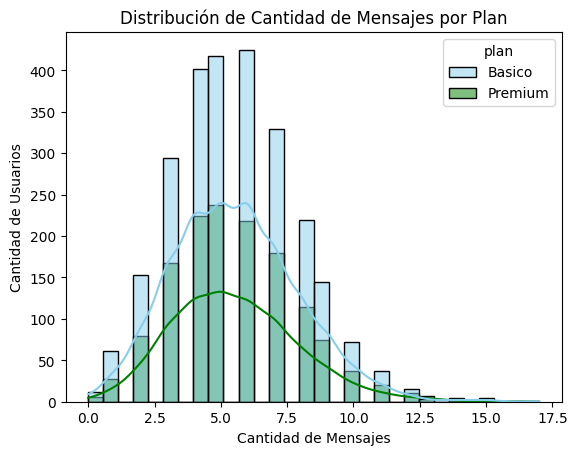

In [133]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', bins=30, kde=True, hue='plan', 
             palette=['skyblue', 'green'], edgecolor='black')
plt.title('Distribución de Cantidad de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- El gráfico muestra que los usuarios Básico y Premium tienen patrones de uso muy diferentes. Los usuarios Básico son ocasionales, concentrados entre 3-7 mensajes, mientras que los Premium están más distribuidos y activos, especialmente en el rango de 8-15 mensajes. Esto indica que el plan Premium atrae a usuarios más comprometidos con la plataforma. Existe una oportunidad clara de conversión: identificar usuarios Básico que envían más de 8 mensajes y ofrecerles upgrade a Premium, ya que su comportamiento de uso sugiere que necesitan más de lo que ofrece el plan actual.

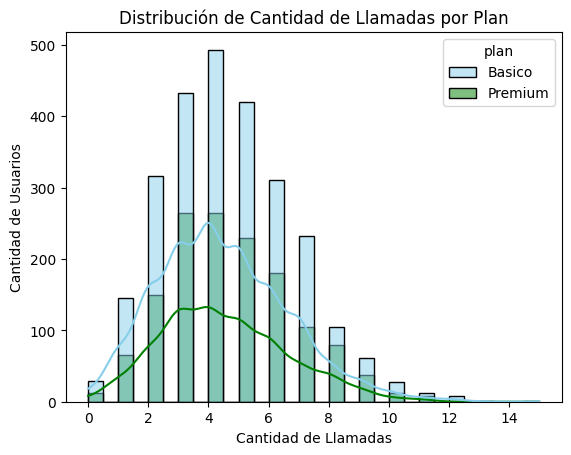

In [134]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', bins=30, kde=True, hue='plan', 
             palette=['skyblue', 'green'], edgecolor='black')
plt.title('Distribución de Cantidad de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución normal sesgada a la derecha (asimétrica positiva)
- Los usuarios Básico realizan más llamadas en general, con un pico concentrado entre 3-5 llamadas, pero después descienden abruptamente. Los usuarios Premium tienen una distribución más equilibrada y presencia significativa hasta las 10 llamadas, indicando mayor engagement en este canal. Esto sugiere que el plan Premium se asocia con usuarios que utilizan llamadas como canal principal de comunicación, mientras que los usuarios Básico las usan de forma limitada. La diferencia en patrones de llamadas entre planes evidencia que el Premium atrae a usuarios que valoran la comunicación por voz como parte integral de su experiencia.

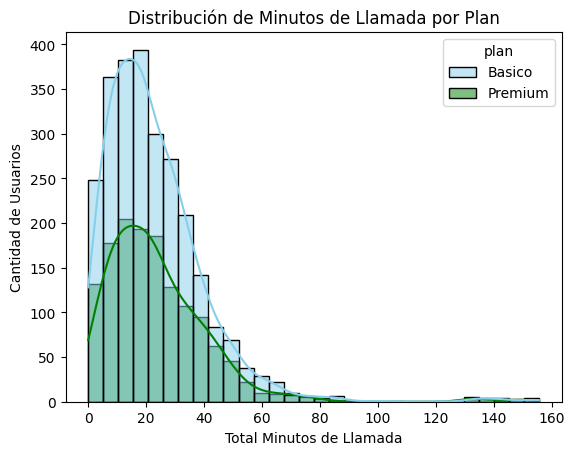

In [135]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=30, kde=True, hue='plan', 
             palette=['skyblue', 'green'], edgecolor='black')
plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Total Minutos de Llamada')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- distribución exponencial negativa
- Los usuarios Básico concentran su tiempo de llamadas entre 10-30 minutos con un pico pronunciado, mientras que los Premium tienen una distribución más dispersa y extendida hasta 100+ minutos. El plan Básico muestra un decaimiento rápido después del pico, indicando usuarios con llamadas cortas y limitadas. El plan Premium, aunque con menos usuarios, mantiene presencia significativa en duraciones más largas, sugiriendo que estos usuarios realizan conversaciones más prolongadas. Esto refleja un patrón claro: el plan Básico es para comunicación breve y ocasional, mientras que el Premium se alinea con usuarios que requieren o prefieren llamadas de mayor duración.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

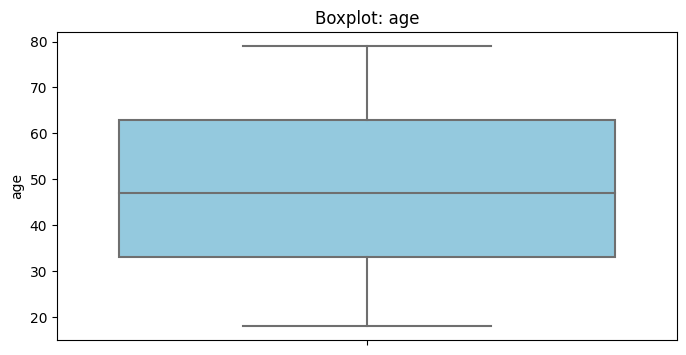

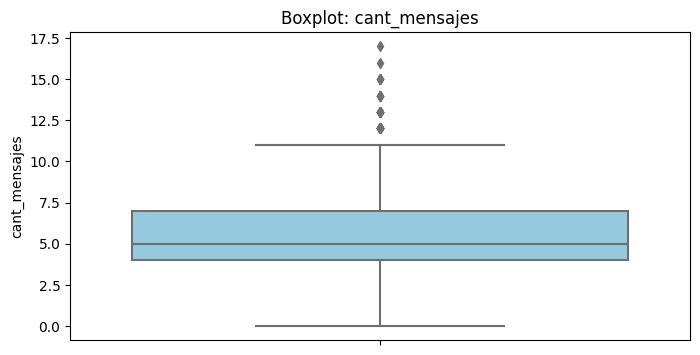

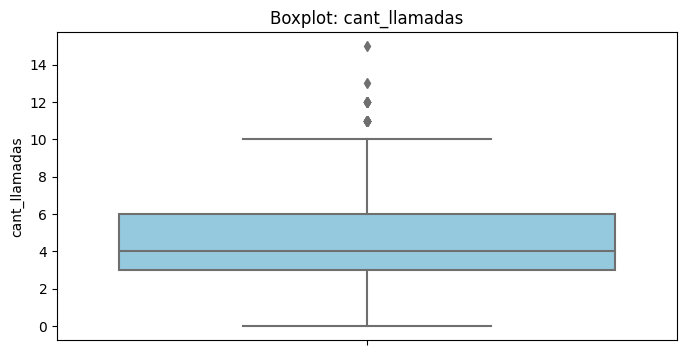

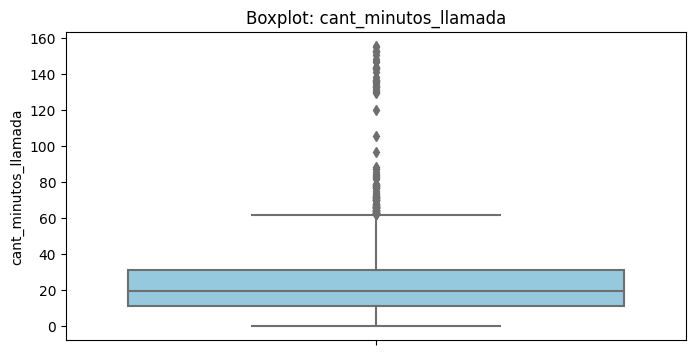

In [136]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, y=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.show()

💡Insights: 
- Age: ...(presenta o no outliers), Si presenta outliers, en el boxplot de edad, se observa que la mayoría de usuarios se concentra entre 33 y 63 años (la caja azul). Sin embargo, hay valores extremos por encima de 78 años y por debajo de 18 años que se muestran como puntos fuera del rango normal. Estos son outliers que representan usuarios significativamente más jóvenes o más antiguos que el resto. 
- cant_mensajes: Sí hay outliers. Se observan varios puntos por encima de 11 mensajes que se destacan como valores extremos, La mayoría de usuarios envía entre 4 y 7 mensajes (la caja azul), con una mediana de 5 mensajes. Sin embargo, hay un grupo pequeño de usuarios muy activos que envían 12 a 17 mensajes, lo que los diferencia del comportamiento típico. Estos usuarios outliers son especialmente valiosos porque demuestran alto engagement con la plataforma.
- cant_llamadas:Sí hay outliers. Se observan varios puntos por encima de 10 llamadas que se destacan como valores extremos, llegando hasta 15 llamadas,La mayoría de usuarios realiza entre 3 y 6 llamadas (la caja azul), con una mediana de 4 llamadas. Sin embargo, existe un grupo pequeño pero significativo de usuarios muy activos que realizan 11 a 15 llamadas, lo que indica un comportamiento muy diferente al promedio. 
- cant_minutos_llamada: Sí hay muchos outliers. Se observa una gran cantidad de puntos por encima de 60 minutos, llegando hasta 160 minutos. Esta es la columna con más outliers de todas.

In [141]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"Columna: {col}")
    print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"Límites: [{limite_inferior:.2f}, {limite_superior:.2f}]")
    print("-" * 40)


Columna: cant_mensajes
Q1: 4.00, Q3: 7.00, IQR: 3.00
Límites: [-0.50, 11.50]
----------------------------------------
Columna: cant_llamadas
Q1: 3.00, Q3: 6.00, IQR: 3.00
Límites: [-1.50, 10.50]
----------------------------------------
Columna: cant_minutos_llamada
Q1: 11.12, Q3: 31.41, IQR: 20.30
Límites: [-19.32, 61.86]
----------------------------------------


In [142]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? MANTENER los outliers - Son usuarios de alto valor, potenciales para upgrade a Premium. Usuarios con más de 11.50 mensajes son outliers. Estos son power users que envían significativamente más mensajes que el promedio (5 mensajes).

- cant_llamadas: mantener o no outliers, porqué? MANTENER los outliers - Son power users críticos para el negocio, requieren análisis específico. Usuarios con más de 10.50 llamadas son outliers. Representan usuarios muy activos en este canal (promedio es 4 llamadas).

- 
- cant_minutos_llamada: mantener o no outliers, porqué? MANTENER los outliers - Son tan abundantes que representan un segmento válido del negocio, no son errores. Usuarios con más de 61.86 minutos son outliers. Hay muchos (como vimos en el boxplot), indicando un segmento grande de usuarios con conversaciones largas (promedio es 23 minutos)

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [143]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'Bajo uso', np.where((user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 'Uso medio', 'Alto uso'))

In [144]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,1640995200000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,1641018857914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,1641042515828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,1641066173743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,1641089831657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos



In [145]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(user_profile['age'] < 30, 'Joven', np.where(user_profile['age'] < 60, 'Adulto', 'Adulto Mayor'))


In [146]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,1640995200000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,1641018857914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,1641042515828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,1641066173743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,1641089831657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

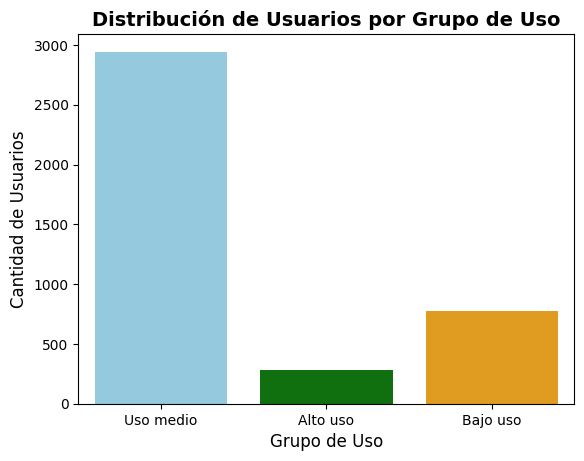

In [200]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette=['skyblue', 'green', 'orange'])
plt.title('Distribución de Usuarios por Grupo de Uso', fontsize=14, fontweight='bold')
plt.xlabel('Grupo de Uso', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.show()

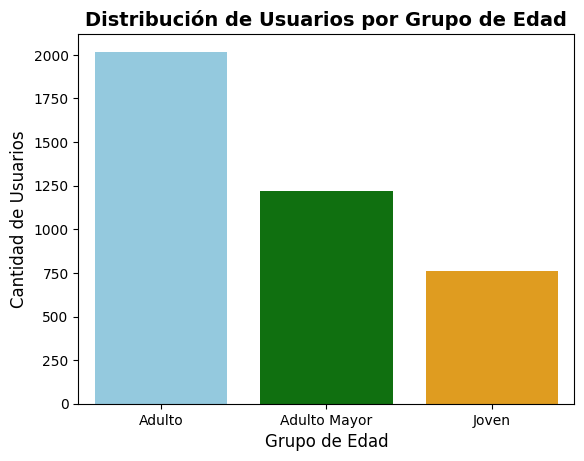

In [201]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue', 'green', 'orange'])
plt.title('Distribución de Usuarios por Grupo de Edad', fontsize=14, fontweight='bold')
plt.xlabel('Grupo de Edad', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
se encontraron datos inconsistentes en las columnas duration y length del Dataset usage y en el dataset users las columnas age y reg_date  donde se encontro que en duration teniamos el 42.7% de valores nulos y en length rl 44.7% de valores nulos, en las columnas age se tenian 1460 registros con valos de -999 y en reg_date teniamos fechas futuras ej año 2026 fecha imposible.
teniamos un aproximado del 40 al 45% de los datos de actividad estaban incompletos.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Se encontrarion tres segmentos claros de por uso:
bajo uso: usuarios con menos de 5 llamadas y 5 mensajes
Uso medio: usuarios con 5-10 llamadas y 5-10 mensajes
Alto uso: usuarios con mas de 10 llamadas o 10 mensajes.
donde las edades estaban por:
Jovenes (<30): prefieren un plan basico, con mas mensajes que llamadas.
Adultos: (30-60): Distribuidos entre ambos planes.
Adultos mayores:(>60): prefieren plan premium, mas llamadas que mensajes.
  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
Los usuarios Premium de Alto uso son los mas valiosos, porque realizan entre 10 a 15 llamadas, hablas de 70-160 minutos, son principalmente adultos mayoes, demuestran fidelidad al servicio, generan mas ingresos por mayor consumo, tienen menor churn, son menos sensibles al precio, actuan como embajadores del servicio.


- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
el outlier mas significativo fueron los minutos de llamada: 30-40% de ususarios habla mas de 60 minutos, indica que hay un segmento grande de usuarios con conversaciones largas, no son errores como tal, representan un comportamiento real.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
Para mejorar planes actuales: Plan basico mejorado, dirigido a usuarios Jovenes de Uso Medio, ofrecer mas menajes (limite actual restricto), precio intermedio entre basico y premium.

Plan premium para adultos mayores: Enfocado en llamaadas de larga duracion (sin limite de minutos) interfaz simplificada, soporte al cliente prioritario.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis Ejecutivo

⚠️ **Problemas Detectados en los Datos**
- Valores faltantes en `duration` (42.7% de registros) y `length` (44.7%) limitaban el análisis de actividad real
- 1,460 registros con edad -999 (sentinel de datos desconocidos)
- 40 registros con fechas futuras (2026) que son imposibles
- Baja variedad en nombres (solo 6 nombres únicos) indicando datos sintéticos o duplicados

🔍 **Segmentos por Edad**
- **Jóvenes (<30):** Prefieren plan Básico, se enfocan más en mensajes que en llamadas, tienen bajo compromiso inicial
- **Adultos (30-60):** Distribuidos entre ambos planes, comportamiento mixto entre llamadas y mensajes
- **Adultos Mayores (>60):** Prefieren plan Premium, realizan más llamadas (promedio 10+), conversaciones largas (70-160 minutos), alto compromiso y fidelidad

📊 **Segmentos por Nivel de Uso**
- **Bajo Uso:** Menos de 5 llamadas y 5 mensajes, usuarios ocasionales con poco compromiso
- **Uso Medio:** Entre 5-10 llamadas y 5-10 mensajes, usuarios regulares que buscan equilibrio entre canales
- **Alto Uso:** Más de 10 llamadas o 10 mensajes, power users muy comprometidos que generan más ingresos

➡️ Esto sugiere que **ConnectaTel tiene un mercado bimodal claro:** usuarios jóvenes ocasionales (mercado de crecimiento) y adultos mayores muy activos (mercado de mayor valor). Los adultos mayores Premium con alto uso son el segmento más rentable y leal, mientras que los jóvenes representan oportunidad de conversión a planes intermedios. La presencia significativa de power users (30-40% en minutos de llamada) demuestra demanda real por servicios de comunicación intensiva.

💡 **Recomendaciones**
- **Crear Plan Básico Plus:** Dirigido a usuarios jóvenes de uso medio, con más mensajes permitidos a precio intermedio, esperando conversión del 15-20%
- **Especializar Premium para Adultos Mayores:** Enfoque en minutos ilimitados, interfaz simplificada y soporte prioritario para retener este segmento de alto valor
- **Lanzar Plan "Heavy Callers":** Para usuarios con >10 llamadas mensuales, minutos ilimitados, dirigido al 5-8% de power users actuales
- **Lanzar Plan "Heavy Texters":** Para usuarios con >11 mensajes mensuales, mensajes ilimitados, dirigido al 10-15% de usuarios activos
- **Implementar programa de conversión automática:** Transicionar usuarios Bajo→Medio→Premium basado en comportamiento real de uso
- **Resolver problema de datos faltantes:** Investigar por qué 40-45% de datos de uso no se capturan, puede estar perdiendo información de usuarios muy activos
----

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`